In [7]:
import pandas as pd

# Load the dataset
df = pd.read_csv('senate_stock_discosures.csv')

# Convert the transaction date to datetime format for proper time-series analysis
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Display the top 5 senators by transaction volume
print("--- Top 5 Senators by Transaction Volume ---")
print(df['last_name'].value_counts().head(5))

# Display the top 5 most traded tickers
print("\n--- Top 5 Traded Tickers ---")
print(df['ticker'].value_counts().head(5))



--- Top 5 Senators by Transaction Volume ---
last_name
Tuberville    1094
Capito         571
Whitehouse     532
Carper         499
Wyden          255
Name: count, dtype: int64

--- Top 5 Traded Tickers ---
ticker
AAPL    109
MSFT     94
CLF      91
PYPL     63
INTC     62
Name: count, dtype: int64


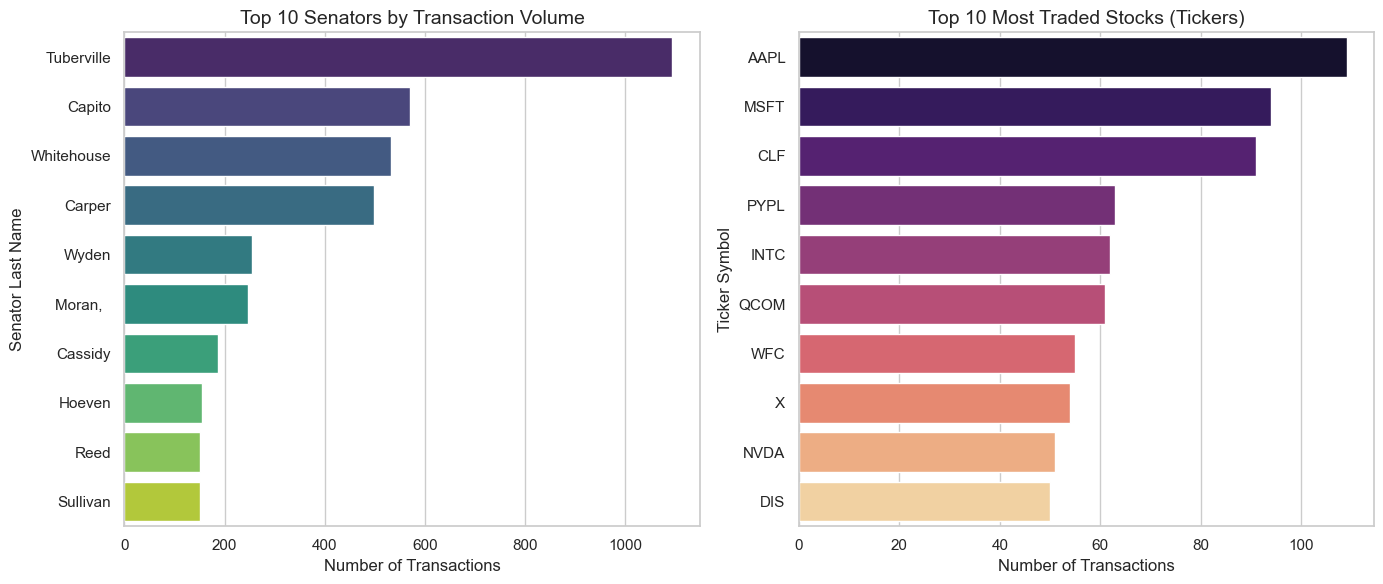

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configure general aesthetics for the plots
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# Plot 1: Top 10 Senators by transaction count
plt.subplot(1, 2, 1)
top_senators = df['last_name'].value_counts().head(10)
sns.barplot(x=top_senators.values, y=top_senators.index, hue=top_senators.index, legend=False, palette='viridis')
plt.title('Top 10 Senators by Transaction Volume', fontsize=14)
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Senator Last Name', fontsize=12)

# Plot 2: Top 10 Tickers by transaction count
plt.subplot(1, 2, 2)
top_tickers = df['ticker'].value_counts().head(10)
sns.barplot(x=top_tickers.values, y=top_tickers.index, hue=top_tickers.index, legend=False, palette='magma')
plt.title('Top 10 Most Traded Stocks (Tickers)', fontsize=14)
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Ticker Symbol', fontsize=12)

# Ensure layout is neat and display the plots
plt.tight_layout()
plt.show()



In [9]:
import scipy.stats as stats

# Extract the upper bounds of asset values for Purchase and Sale transactions
purchases = df[df['transaction'].str.contains('Purchase', na=False)]['asset_value_high']
sales = df[df['transaction'].str.contains('Sale', na=False)]['asset_value_high']

# Perform Welch's t-test (assuming unequal variances) to compare investment sizes
t_stat, p_value = stats.ttest_ind(purchases, sales, equal_var=False)

# Print the statistical results
print("--- Hypothesis Test Results ---")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")
print("-" * 30)

# Evaluate the null hypothesis
if p_value < 0.05:
    print("Conclusion: Reject H0")
    print("There is a statistically significant difference between the investment amounts of purchase and sale transactions.")
else:
    print("Conclusion: Fail to reject H0")
    
    print("There is no statistically significant difference between the investment amounts of purchase and sale transactions.")
    

--- Hypothesis Test Results ---
T-Statistic: 0.5963
P-Value: 0.5510
------------------------------
Conclusion: Fail to reject H0
There is no statistically significant difference between the investment amounts of purchase and sale transactions.


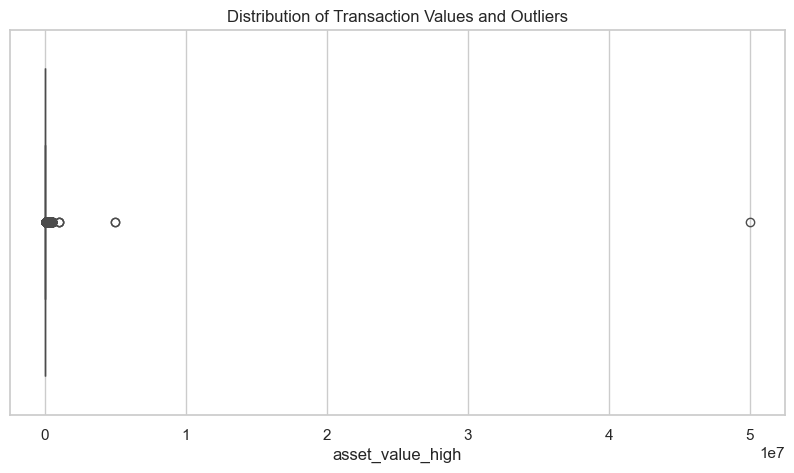

Mean transaction value: 49248.78
Median transaction value: 15000.00


In [10]:
# Outlier detection: Extremely high transaction values can skew our results
# Let's check the distribution of asset_value_high
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['asset_value_high'])
plt.title('Distribution of Transaction Values and Outliers')
plt.show()

# Calculate the mean and median to see if there is a significant gap
print(f"Mean transaction value: {df['asset_value_high'].mean():.2f}")
print(f"Median transaction value: {df['asset_value_high'].median():.2f}")

In [11]:
from scipy.stats import shapiro

# Statistical normality test (Shapiro-Wilk)
# Testing if the distribution of transaction amounts is normal
stat, p = shapiro(df['asset_value_high'].head(500)) # Sample of 500 for performance
print(f"Shapiro-Wilk Test P-value: {p:.4f}")

if p > 0.05:
    print("Data follows a normal distribution. T-test is highly reliable.")
else:
    print("Data does not follow a normal distribution. Welch's T-test is preferred due to robustness.")
    

Shapiro-Wilk Test P-value: 0.0000
Data does not follow a normal distribution. Welch's T-test is preferred due to robustness.


--- TOP 10 SENATORS WITH FOCUSED PORTFOLIOS ---
       last_name  focus_score
19  Manchin, III     1.000000
7         Cornyn     1.000000
18        Lummis     1.000000
31         Thune     1.000000
16       Kennedy     1.000000
27         Rosen     1.000000
28         Scott     1.000000
35         Vance     1.000000
3     Casey, Jr.     1.000000
5        Collins     0.866657


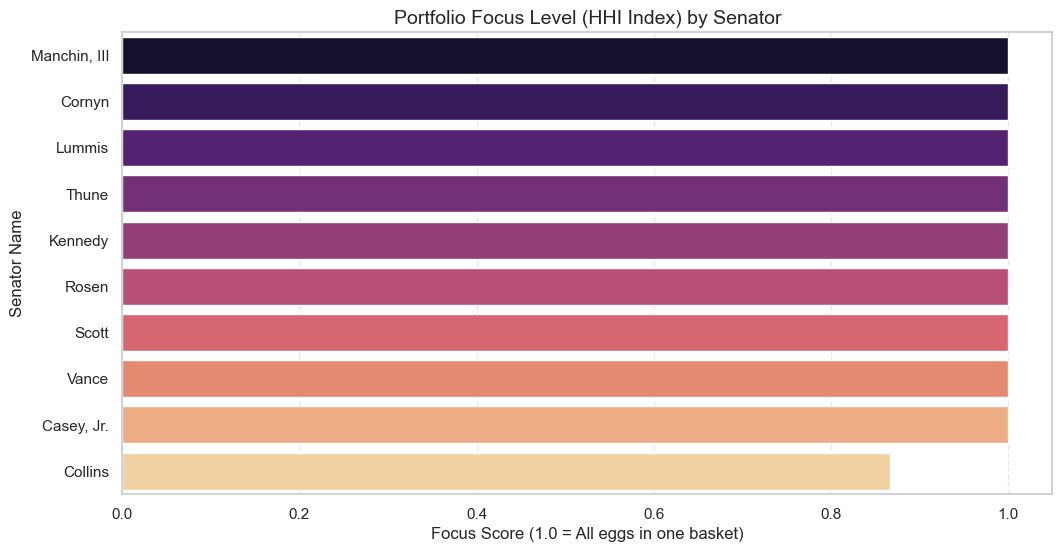

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# This function checks if a senator is putting all their money in one place.
# 1.0 = All-in on one stock. 0.0 = Fully diversified.
def calculate_hhi(group):
    if group.sum() == 0:
        return 0
    # Weights are the percentage of each stock in the senator's portfolio
    weights = group / group.sum()
    return (weights**2).sum()


# We group by senator and ticker to see the total amount spent per stock
portfolio_totals = df.groupby(['last_name', 'ticker'])['asset_value_high'].sum().reset_index()


# Calculate the focus score (HHI) for every senator.
hhi_analysis = portfolio_totals.groupby('last_name')['asset_value_high'].apply(calculate_hhi).reset_index()
hhi_analysis.columns = ['last_name', 'focus_score']

# Sort to find the top 10 most 'focused' (non-diversified) traders
top_focus_senators = hhi_analysis.sort_values(by='focus_score', ascending=False).head(10)

#PRINT RESULTS
print("--- TOP 10 SENATORS WITH FOCUSED PORTFOLIOS ---")
print(top_focus_senators)

# for VISUALIZATION 
plt.figure(figsize=(12, 6))

# We assign 'last_name' to 'hue' to avoid the library warning
sns.barplot(
    data=top_focus_senators, 
    x='focus_score', 
    y='last_name', 
    hue='last_name', 
    palette='magma', 
    legend=False
)

plt.title('Portfolio Focus Level (HHI Index) by Senator', fontsize=14)
plt.xlabel('Focus Score (1.0 = All eggs in one basket)', fontsize=12)
plt.ylabel('Senator Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


Focus Score and Total Investment per Senator:
       last_name  focus_score  total_invested
7         Cornyn     1.000000          100000
19  Manchin, III     1.000000          100000
35         Vance     1.000000          100000
31         Thune     1.000000           50000
28         Scott     1.000000           45000
3     Casey, Jr.     1.000000           15000
16       Kennedy     1.000000           15000
18        Lummis     1.000000           15000
27         Rosen     1.000000           15000
5        Collins     0.866657        53820000


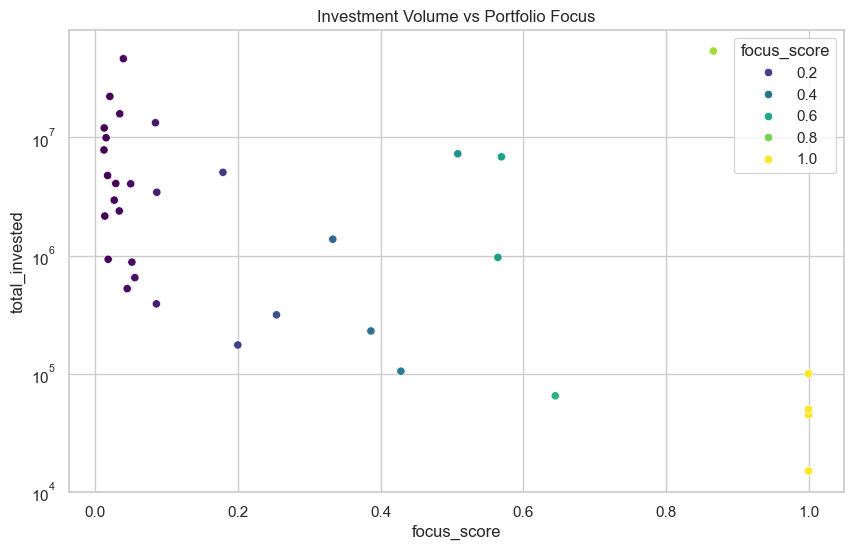

In [12]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# A 1.0 Focus Score is meaningless if the total amount is small. 
# We need to filter for the 'Heavy Hitters'—Senators who 
# trade big amounts AND keep their portfolio focused.

# calculate focus score (HHI)
def calculate_hhi(group):
    if group.sum() == 0:
        return 0
    weights = group / group.sum()
    return (weights**2).sum()

# get total volume and focus score per senator
portfolio_totals = df.groupby(['last_name', 'ticker'])['asset_value_high'].sum().reset_index()
hhi_scores = portfolio_totals.groupby('last_name')['asset_value_high'].apply(calculate_hhi).reset_index()
hhi_scores.columns = ['last_name', 'focus_score']

total_volumes = df.groupby('last_name')['asset_value_high'].sum().reset_index()
total_volumes.columns = ['last_name', 'total_invested']

# merge everything into one table
final_analysis = pd.merge(hhi_scores, total_volumes, on='last_name')

# sort by focus and then by volume to find the real players
top_players = final_analysis.sort_values(by=['focus_score', 'total_invested'], ascending=[False, False]).head(10)

print("Focus Score and Total Investment per Senator:")
print(top_players)

# simple scatter plot to see the big picture
plt.figure(figsize=(10, 6))
sns.scatterplot(data=final_analysis, x='focus_score', y='total_invested', hue='focus_score', palette='viridis')
plt.title('Investment Volume vs Portfolio Focus')
plt.yscale('log') # using log scale because of the huge difference in amounts
plt.show()

Detailed Timeline of Trades:
       last_name  year ticker  asset_value_high
20       Collins  2015    MMM          50050000
14       Collins  2015    AXP            165000
34       Collins  2016   SRCL            150000
17       Collins  2015    HAL            120000
9        Collins  2014  TOLLX            120000
88         Vance  2023    WMT            100000
35       Collins  2016   TSCO            100000
30       Collins  2016   HOLX            100000
25       Collins  2016    COP            100000
24       Collins  2016    AWK            100000
15       Collins  2015    AYI            100000
18       Collins  2015    HSY            100000
87  Manchin, III  2017   HBAN            100000
64       Collins  2018    STZ            100000
1        Collins  2014  BMGAX             90000


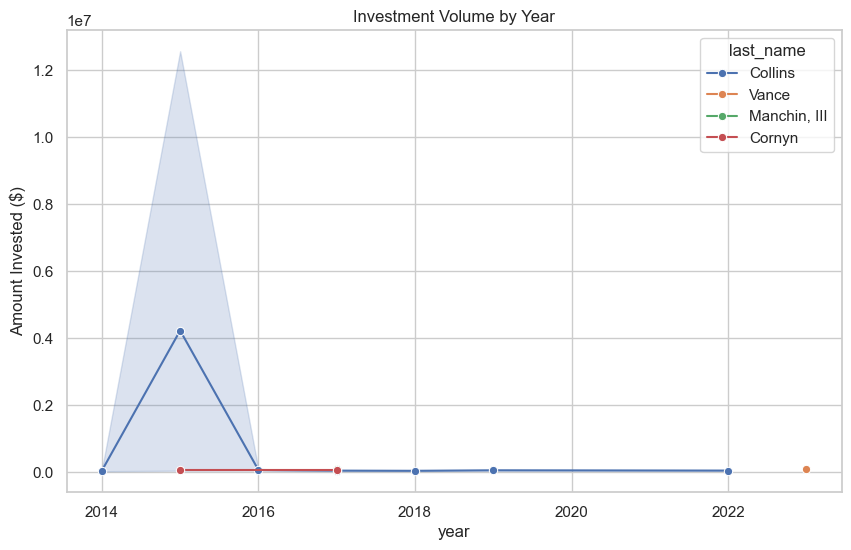

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# convert dates to datetime format and extract the year
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['year'] = df['transaction_date'].dt.year

# filter the dataframe for our target whales
target_whales = ['Collins', 'Cornyn', 'Manchin, III', 'Vance']
whale_details = df[df['last_name'].isin(target_whales)]

# group by senator, year, and ticker to see where the money went
yearly_breakdown = whale_details.groupby(['last_name', 'year', 'ticker'])['asset_value_high'].sum().reset_index()

# sort by investment amount in descending order
yearly_breakdown = yearly_breakdown.sort_values(by=['asset_value_high'], ascending=False)

print("Detailed Timeline of Trades:")
print(yearly_breakdown.head(15))

# visualize the investment timeline for these specific senators
plt.figure(figsize=(10, 6))
sns.lineplot(data=yearly_breakdown, x='year', y='asset_value_high', hue='last_name', marker='o')
plt.title('Investment Volume by Year')
plt.ylabel('Amount Invested ($)')
plt.show()
